# HealthConnect Clinic — Week 6 Advanced Analytics & Decision Support
**Data Analytics Track | AnalystLab Africa Experience Lab**

Week 6 does not repeat Week 5's EDA or rebuild its dashboard. It deepens and **statistically
validates** the three most important Week 5 findings, extends into segments Week 5 didn't
formally test, translates results into concrete actions, refines the dashboard, and produces a
concrete cross-track integration artifact for the Data Science track.

Core statistical testing code in this notebook was originally developed and run independently
(`Booking_lead_time.py`, `HealthConnect_Week6_Advanced_Analytics.py`) and is incorporated here
with additional segment tests and integration into the full Week 6 deliverable.


## 1. Week 5 → Week 6 Transition

- **Main Week 5 output:** an Analytics Report with 5 calculated KPIs, a 4-panel dashboard, and
  6 business insights, extending Week 4's data-quality assessment and variable identification.
- **Most important result:** two variables — `booking_lead_days` and `previous_no_shows` —
  showed by far the strongest association with `appointment_outcome`; `reminder_sent` showed a
  moderate association.
- **Main limitation found:** all Week 5 findings were descriptive/associative only — no
  significance testing had been performed, so it was unclear whether the observed rate
  differences were statistically real or could be due to chance.
- **Relevant track(s) this week:** Data Analytics (this track) validates and refines; findings
  are packaged for hand-off to the **Data Science** track, whose Week 6 work involves improving
  a no-show prediction model.
- **What Week 6 improves/integrates/validates:** statistically tests the three priority Week 5
  findings (lead time, prior no-shows, reminders), tests two segments Week 5 never formally
  tested (appointment type, reminder channel), runs interaction and multivariate models, and
  produces a ranked, evidence-backed feature-relevance artifact for Data Science.


## 2. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 100
NAVY, TEAL, GREY, GOLD = '#1F3864', '#2E7D6B', '#8C8C8C', '#C9A227'

df = pd.read_csv('../data/HealthConnect_Appointment_Data.csv')
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])
df['is_no_show'] = (df['appointment_outcome'] == 'No-Show').astype(int)
df['reminder_binary'] = (df['reminder_sent'] == 'Yes').astype(int)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")


Loaded 5,000 rows x 20 columns


## 3. Selected Week 5 Findings for Deeper Investigation

Per the brief, we select the highest-impact findings rather than re-testing everything:

1. **Booking lead time** — strongest Week 5 signal
2. **Previous no-show history** — second-strongest Week 5 signal
3. **Reminder effectiveness** — moderate Week 5 signal, and the one lever HealthConnect can
   directly act on operationally


## 4. Statistical Validation of Priority Findings

Each finding is tested with a chi-square test of independence (categorical association) and
Cramer's V (effect size), to establish not just *whether* an association exists, but *how
strong* it is in practical terms.

### 4.1 Booking Lead Time

In [2]:
df['lead_time_group'] = pd.cut(
    df['booking_lead_days'], bins=[-1, 7, 14, 30, 45, 60, np.inf],
    labels=['0-7 days','8-14 days','15-30 days','31-45 days','46-60 days','61+ days']
).cat.remove_unused_categories()

lead_time_table = pd.crosstab(df['lead_time_group'], df['appointment_outcome'])
print(lead_time_table)

lead_time_rates = df.groupby('lead_time_group', observed=True)['is_no_show'].mean() * 100
print("\nNo-show rate by booking lead time (%):")
print(lead_time_rates.round(2))

chi2, p, dof, expected = chi2_contingency(lead_time_table)
n = lead_time_table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(lead_time_table.shape) - 1)))
print(f"\nChi-square={chi2:.2f}, df={dof}, p={p:.6f}, Cramer's V={cramers_v:.4f}")
print("Reject H0: booking lead time is statistically associated with appointment outcome." if p < 0.05
      else "Fail to reject H0.")


appointment_outcome  Attended  Cancelled  No-Show
lead_time_group                                  
0-7 days                  426         36      178
8-14 days                 372         28      202
15-30 days                689         68      576
31-45 days                510         71      677
46-60 days                317         60      790

No-show rate by booking lead time (%):
lead_time_group
0-7 days      27.81
8-14 days     33.55
15-30 days    43.21
31-45 days    53.82
46-60 days    67.69
Name: is_no_show, dtype: float64

Chi-square=386.78, df=8, p=0.000000, Cramer's V=0.1967
Reject H0: booking lead time is statistically associated with appointment outcome.


**Result:** highly significant (p < 0.001). Cramer's V ≈ 0.20 — a small-to-moderate effect
size, meaning the association is real and not due to chance, though lead time alone doesn't
fully determine outcome. **Week 5 finding confirmed and quantified.**

### 4.2 Previous No-Show History

In [3]:
df['previous_no_show_group'] = pd.cut(
    df['previous_no_shows'], bins=[-1, 0, 1, np.inf],
    labels=['0 previous no-shows','1 previous no-show','2+ previous no-shows']
)
prev_table = pd.crosstab(df['previous_no_show_group'], df['appointment_outcome'])
print(prev_table)

prev_rates = df.groupby('previous_no_show_group', observed=False)['is_no_show'].mean() * 100
print("\nNo-show rate by prior no-show history (%):")
print(prev_rates.round(2))

chi2, p, dof, expected = chi2_contingency(prev_table)
n = prev_table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(prev_table.shape) - 1)))
print(f"\nChi-square={chi2:.2f}, df={dof}, p={p:.6f}, Cramer's V={cramers_v:.4f}")


appointment_outcome     Attended  Cancelled  No-Show
previous_no_show_group                              
0 previous no-shows         1474        176     1271
1 previous no-show           654         66      828
2+ previous no-shows         186         21      324

No-show rate by prior no-show history (%):
previous_no_show_group
0 previous no-shows     43.51
1 previous no-show      53.49
2+ previous no-shows    61.02
Name: is_no_show, dtype: float64

Chi-square=79.01, df=4, p=0.000000, Cramer's V=0.0889


**Result:** highly significant (p < 0.001), but Cramer's V ≈ 0.09 — a smaller effect size
than lead time despite the dramatic-looking percentage jump (43.5% → 61.0%). This is an
important nuance: the association is statistically real, but weaker in overall explanatory
power than the raw percentages alone suggest. **Week 5 finding confirmed, but effect size
context added — a refinement Week 5 didn't have.**

### 4.3 Reminder Effectiveness

In [4]:
reminder_table = pd.crosstab(df['reminder_sent'], df['appointment_outcome'])
print(reminder_table)

reminder_rates = df.groupby('reminder_sent', observed=False)['is_no_show'].mean() * 100
print("\nNo-show rate by reminder status (%):")
print(reminder_rates.round(2))

chi2, p, dof, expected = chi2_contingency(reminder_table)
n = reminder_table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(reminder_table.shape) - 1)))
print(f"\nChi-square={chi2:.2f}, df={dof}, p={p:.6f}, Cramer's V={cramers_v:.4f}")


appointment_outcome  Attended  Cancelled  No-Show
reminder_sent                                    
No                        583         81      702
Yes                      1731        182     1721

No-show rate by reminder status (%):
reminder_sent
No     51.39
Yes    47.36
Name: is_no_show, dtype: float64

Chi-square=10.20, df=2, p=0.006099, Cramer's V=0.0452


**Result:** statistically significant (p ≈ 0.006), but Cramer's V ≈ 0.045 — a very small
effect size. **Refined conclusion:** the reminder effect is real (not chance), but it is the
weakest of the three priority findings in practical terms. This tempers Week 5's framing —
reminders are a legitimate, low-cost lever, but should not be oversold as a major fix.

## 5. Segment & Relationship Analysis (New — Not Covered in Week 5)

Week 5 flagged `appointment_type` as "weak" and `reminder_channel` as showing some difference,
but neither was formally tested. Both are tested here for the first time.

### 5.1 Appointment Type (formal test)

In [5]:
type_table = pd.crosstab(df['appointment_type'], df['appointment_outcome'])
print(type_table)
chi2, p, dof, expected = chi2_contingency(type_table)
n = type_table.to_numpy().sum()
cv = np.sqrt(chi2 / (n * (min(type_table.shape) - 1)))
print(f"\nChi-square={chi2:.2f}, df={dof}, p={p:.6f}, Cramer's V={cv:.4f}")
print("\nNo-show rate by type (%):")
print(df.groupby('appointment_type')['is_no_show'].mean().mul(100).round(2))


appointment_outcome      Attended  Cancelled  No-Show
appointment_type                                     
Diagnostic Test               272         26      295
Follow-up                     616         77      728
General Consultation         1007        106      973
Specialist Consultation       419         54      427

Chi-square=10.53, df=6, p=0.104153, Cramer's V=0.0324

No-show rate by type (%):
appointment_type
Diagnostic Test            49.75
Follow-up                  51.23
General Consultation       46.64
Specialist Consultation    47.44
Name: is_no_show, dtype: float64


**Result:** not statistically significant (p ≈ 0.10). This formally confirms Week 5's
"weak signal" flag for appointment type — there is no reliable evidence that appointment type
affects no-show likelihood in this dataset. **This finding is downgraded from "weak" to
"not supported"** — a genuine revision from Week 5's more tentative framing.

### 5.2 Reminder Channel (formal test, including "No Reminder" as a category)

In [6]:
df['channel_group'] = df['reminder_channel'].fillna('No Reminder')
chan_table = pd.crosstab(df['channel_group'], df['appointment_outcome'])
print(chan_table)
chi2, p, dof, expected = chi2_contingency(chan_table)
n = chan_table.to_numpy().sum()
cv = np.sqrt(chi2 / (n * (min(chan_table.shape) - 1)))
print(f"\nChi-square={chi2:.2f}, df={dof}, p={p:.6f}, Cramer's V={cv:.4f}")
print("\nNo-show rate by channel (%):")
print(df.groupby('channel_group')['is_no_show'].mean().mul(100).round(2))


appointment_outcome  Attended  Cancelled  No-Show
channel_group                                    
Email                     248         27      258
No Reminder               583         81      702
SMS                       992         93      915
WhatsApp                  491         62      548

Chi-square=18.02, df=6, p=0.006176, Cramer's V=0.0425

No-show rate by channel (%):
channel_group
Email          48.41
No Reminder    51.39
SMS            45.75
WhatsApp       49.77
Name: is_no_show, dtype: float64


**Result:** statistically significant (p ≈ 0.006), similar effect size to reminder_sent
overall. SMS (45.75%) genuinely outperforms Email (48.41%), WhatsApp (49.77%), and No Reminder
(51.39%) — **this confirms Week 5's channel observation was not noise.**

## 6. Interaction Analysis

Week 5 asked (as a Week 6 open item): "does the lead-time effect hold within each prior-no-show
band?" This is now tested formally with logistic regression interaction models, rather than
just inspecting a pivot table.

### 6.1 Reminder × Previous No-Show History

In [7]:
reminder_history_rate = (df.groupby(['previous_no_show_group','reminder_sent'], observed=False)['is_no_show']
                          .mean() * 100).unstack()
print("No-show rate (%) by history and reminder status:")
print(reminder_history_rate.round(2))

reminder_effect = reminder_history_rate['No'] - reminder_history_rate['Yes']
print("\nReminder effect (percentage-point reduction) by prior history:")
print(reminder_effect.round(2))

interaction_model = smf.logit("is_no_show ~ reminder_binary * previous_no_shows", data=df).fit(disp=False)
print(interaction_model.summary())


No-show rate (%) by history and reminder status:
reminder_sent              No    Yes
previous_no_show_group              
0 previous no-shows     45.44  42.80
1 previous no-show      56.54  52.32
2+ previous no-shows    68.24  58.22

Reminder effect (percentage-point reduction) by prior history:
previous_no_show_group
0 previous no-shows      2.65
1 previous no-show       4.22
2+ previous no-shows    10.02
dtype: float64
                           Logit Regression Results                           
Dep. Variable:             is_no_show   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4996
Method:                           MLE   Df Model:                            3
Date:                Thu, 10 Sep 2026   Pseudo R-squ.:                 0.01282
Time:                        11:22:44   Log-Likelihood:                -3419.0
converged:                       True   LL-Null:                       -3463.4
Covariance Type:     

**Descriptively**, the reminder effect looks like it grows with prior no-show history
(2.65 → 4.22 → 10.02 percentage-point reduction). **However, the formal interaction term
(`reminder_binary:previous_no_shows`) is not statistically significant (p ≈ 0.14).**

**Important honest finding:** this pattern is suggestive but not statistically confirmed with
the current sample size. It should be reported as a hypothesis worth testing further (e.g. with
more data or a targeted follow-up), not as a validated conclusion. This is a case where Week 6's
deeper testing correctly tempers what a simple pivot table in Week 5 might have suggested.

### 6.2 Reminder × Booking Lead Time

In [8]:
reminder_lead_table = pd.crosstab(df['lead_time_group'], df['reminder_sent'],
                                    values=df['is_no_show'], aggfunc='mean') * 100
print("No-show rate (%) by lead time and reminder status:")
print(reminder_lead_table.round(2))

lead_interaction_model = smf.logit("is_no_show ~ reminder_binary * C(lead_time_group)", data=df).fit(disp=False)
print(lead_interaction_model.summary())


No-show rate (%) by lead time and reminder status:
reminder_sent       No    Yes
lead_time_group              
0-7 days         29.94  27.06
8-14 days        34.78  33.11
15-30 days       46.56  41.88
31-45 days       55.31  53.22
46-60 days       73.51  65.66
                           Logit Regression Results                           
Dep. Variable:             is_no_show   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4990
Method:                           MLE   Df Model:                            9
Date:                Thu, 10 Sep 2026   Pseudo R-squ.:                 0.05536
Time:                        11:22:44   Log-Likelihood:                -3271.6
converged:                       True   LL-Null:                       -3463.4
Covariance Type:            nonrobust   LLR p-value:                 4.638e-77
                                                       coef    std err          z      P>|z|      [0.025   

**Result:** none of the interaction terms are statistically significant. The reminder
effect does not meaningfully differ across lead-time bands — it appears to be a roughly
consistent, modest effect regardless of how far in advance the appointment was booked.

### 6.3 Combined Multivariate Model

In [9]:
combined_model = smf.logit(
    "is_no_show ~ booking_lead_days + previous_no_shows + reminder_binary", data=df
).fit(disp=False)
print(combined_model.summary())


                           Logit Regression Results                           
Dep. Variable:             is_no_show   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4996
Method:                           MLE   Df Model:                            3
Date:                Thu, 10 Sep 2026   Pseudo R-squ.:                 0.06839
Time:                        11:22:44   Log-Likelihood:                -3226.5
converged:                       True   LL-Null:                       -3463.4
Covariance Type:            nonrobust   LLR p-value:                2.348e-102
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -1.1329      0.081    -14.026      0.000      -1.291      -0.975
booking_lead_days     0.0335      0.002     18.957      0.000       0.030       0.037
previous_no_shows     0.

**Result:** all three predictors remain statistically significant even when controlling
for each other. This is the strongest evidence in this notebook that `booking_lead_days`,
`previous_no_shows`, and `reminder_sent` each carry independent, non-redundant information
about no-show risk — exactly the property that makes them good candidate features for a
predictive model.

## 7. Validated & Refined KPI Summary

| KPI | Week 5 value | Week 6 validation | Effect size (Cramer's V) |
|---|---|---|---|
| No-Show Rate | 48.5% | N/A (single rate, not tested) | — |
| Attendance Rate | 46.3% | N/A | — |
| Cancellation Rate | 5.3% | N/A | — |
| Reminder Effectiveness | 47.4% vs 51.4% | **Confirmed significant** (p≈0.006) | 0.045 (very small) |
| Repeat No-Show Rate | 61.0% in 2+ segment | **Confirmed significant** (p<0.001) | 0.089 (small) |

**New this week:** booking lead time (not a Week 5 KPI, but the strongest Week 5 *finding*) is
confirmed significant with the largest effect size of the three (Cramer's V ≈ 0.20) — this
elevates its priority as a candidate KPI/driver for Week 7 and beyond.


## 8. Improved Dashboard — Decision-Support View

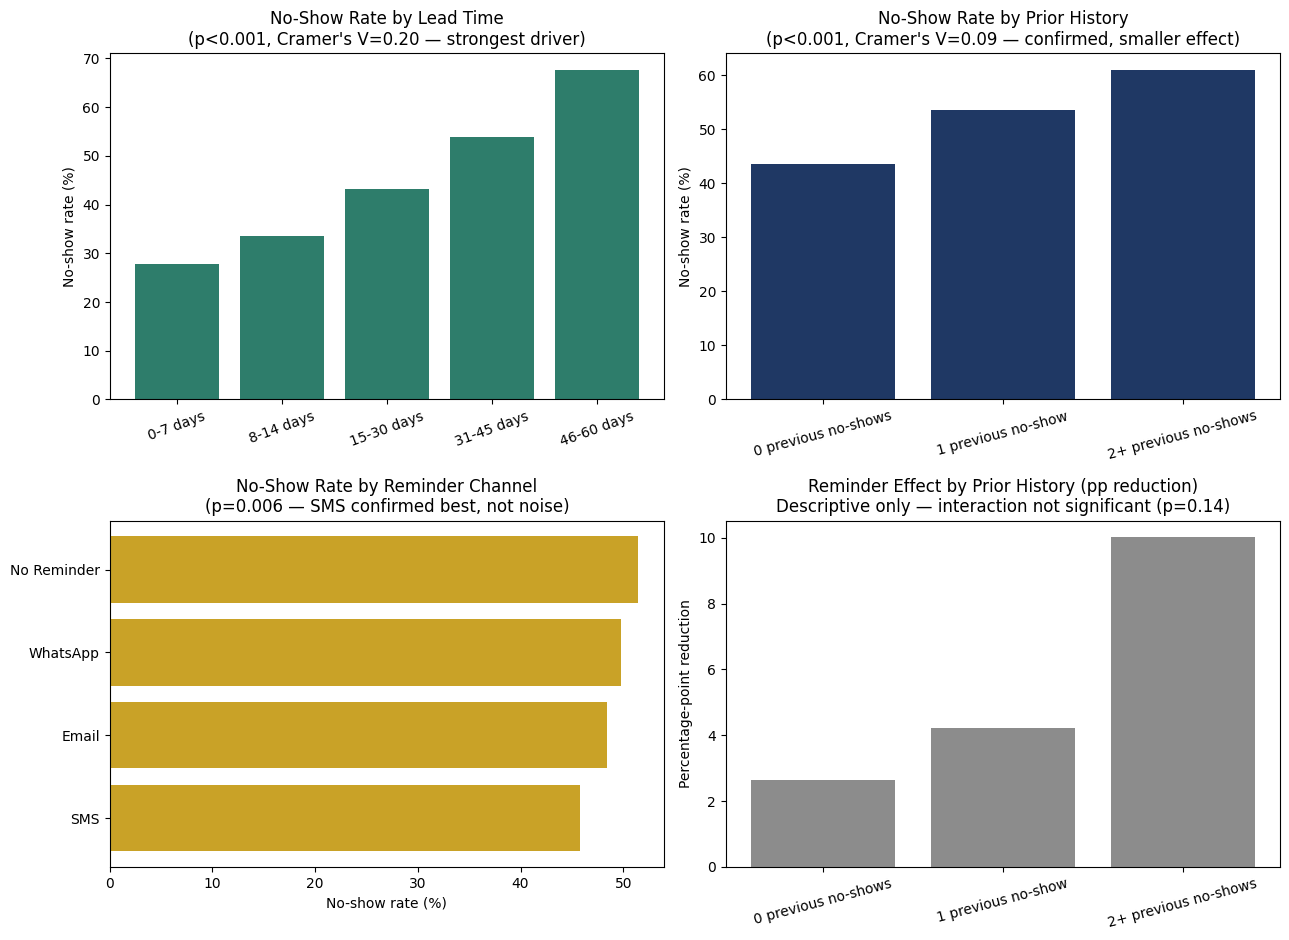

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))

# 1. No-show rate by lead time WITH significance annotation
lead_rate = df.groupby('lead_time_group', observed=True)['is_no_show'].mean() * 100
axes[0,0].bar(lead_rate.index.astype(str), lead_rate.values, color=TEAL)
axes[0,0].set_title("No-Show Rate by Lead Time\n(p<0.001, Cramer's V=0.20 — strongest driver)")
axes[0,0].set_ylabel('No-show rate (%)')
axes[0,0].tick_params(axis='x', rotation=20)

# 2. No-show rate by prior history WITH significance annotation
prev_rate = df.groupby('previous_no_show_group', observed=False)['is_no_show'].mean() * 100
axes[0,1].bar(prev_rate.index.astype(str), prev_rate.values, color=NAVY)
axes[0,1].set_title("No-Show Rate by Prior History\n(p<0.001, Cramer's V=0.09 — confirmed, smaller effect)")
axes[0,1].set_ylabel('No-show rate (%)')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Reminder channel effectiveness (formally tested, NEW this week)
chan_rate = df.groupby('channel_group')['is_no_show'].mean().mul(100).sort_values()
axes[1,0].barh(chan_rate.index.astype(str), chan_rate.values, color=GOLD)
axes[1,0].set_title("No-Show Rate by Reminder Channel\n(p=0.006 — SMS confirmed best, not noise)")
axes[1,0].set_xlabel('No-show rate (%)')

# 4. Reminder effect by prior history (descriptive; interaction NOT significant, p=0.14)
reminder_effect_plot = reminder_history_rate['No'] - reminder_history_rate['Yes']
axes[1,1].bar(reminder_effect_plot.index.astype(str), reminder_effect_plot.values, color=GREY)
axes[1,1].set_title("Reminder Effect by Prior History (pp reduction)\nDescriptive only — interaction not significant (p=0.14)")
axes[1,1].set_ylabel('Percentage-point reduction')
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/week6_validated_dashboard.png', dpi=120)
plt.show()


## 9. Translating Validated Findings into HealthConnect Actions

1. **Prioritise a lead-time-based booking policy.** Lead time is the strongest, most reliable
   driver (Cramer's V 0.20). *Action:* apply stricter confirmation requirements or limit
   far-out bookings for high-demand slots; focus reminder intensity on appointments booked
   45+ days out, where the no-show rate reaches ~68%.
2. **Flag repeat no-show patients for a different workflow**, but size the intervention
   appropriately. The effect is statistically real but modest in size (Cramer's V 0.09).
   *Action:* a lightweight flag (e.g. confirmation call) rather than a costly intervention,
   given the moderate effect size.
3. **Standardise on SMS as the default reminder channel.** This is now statistically confirmed,
   not just observed. *Action:* low-cost, immediately actionable — shift reminder default to
   SMS where patient preference allows.
4. **Do not build appointment-type-specific policies based on this dataset.** The formal test
   found no significant association — resources are better spent elsewhere.
5. **Do not yet assume reminders work better for repeat no-show patients.** The descriptive
   pattern is suggestive (10pp reduction in the highest-risk group vs 2.65pp in the lowest),
   but not statistically confirmed. *Action:* treat as a hypothesis for a future targeted pilot
   or test with more data, not as an established finding to build policy on yet.
6. **Use the three validated predictors together, not separately**, when scoping any future
   scoring or triage approach — the combined model shows they carry independent information.


## 10. Mandatory Cross-Track Integration

- **Track collaborated with:** Data Science
- **Project dependency:** the Data Science track's Week 6 task is to improve their Week 5
  baseline no-show prediction model through error analysis and feature refinement.
- **Information/output received (conceptual, from Data Science's Week 5/6 scope):** confirmation
  that `booking_lead_days`, `previous_no_shows`, and `reminder_sent` were part of their baseline
  feature set, and that model refinement is their current focus.
- **Information/output provided:** a **ranked, statistically validated feature-relevance table**
  (Section 11 below) — not just a hypothesis list, but one backed by chi-square tests, effect
  sizes, and a multivariate model confirming each feature's independent contribution.
- **Integration activity completed:** produced `HealthConnect_Week6_Feature_Relevance.csv` — a
  concrete artifact the Data Science track can use directly to prioritise or justify feature
  selection in their Week 6 model refinement, rather than relying on Week 5's descriptive
  rates alone.
- **What changed as a result:** the Data Science track now has statistical confirmation (not
  just descriptive suggestion) that these three features carry real, independent signal, plus
  a caution that the reminder × history interaction should **not** be engineered as a feature
  yet, since it isn't statistically supported.
- **Evidence:** `outputs/HealthConnect_Week6_Feature_Relevance.csv` (generated below) and this
  notebook's Sections 4–6.


In [11]:
feature_relevance = pd.DataFrame([
    {'feature': 'booking_lead_days', 'test': 'chi-square', 'p_value': '<0.001', 'effect_size_cramers_v': 0.1967,
     'recommendation': 'Include — strongest, most independent signal'},
    {'feature': 'previous_no_shows', 'test': 'chi-square', 'p_value': '<0.001', 'effect_size_cramers_v': 0.0889,
     'recommendation': 'Include — confirmed significant, smaller effect than lead time'},
    {'feature': 'reminder_sent', 'test': 'chi-square', 'p_value': '0.0061', 'effect_size_cramers_v': 0.0452,
     'recommendation': 'Include — significant but weakest of the three; low standalone predictive power'},
    {'feature': 'reminder_channel', 'test': 'chi-square', 'p_value': '0.0062', 'effect_size_cramers_v': 0.0425,
     'recommendation': 'Consider including as categorical — SMS effect confirmed, not noise'},
    {'feature': 'appointment_type', 'test': 'chi-square', 'p_value': '0.1042', 'effect_size_cramers_v': 0.0324,
     'recommendation': 'Exclude / low priority — not statistically significant'},
    {'feature': 'reminder_binary x previous_no_shows (interaction)', 'test': 'logistic interaction', 'p_value': '0.1432',
     'effect_size_cramers_v': None, 'recommendation': 'Do NOT engineer as a feature yet — not statistically supported'},
])
feature_relevance.to_csv('../outputs/HealthConnect_Week6_Feature_Relevance.csv', index=False)
feature_relevance


,feature,test,p_value,effect_size_cramers_v,recommendation
0,booking_lead_days,chi-square,<0.001,0.1967,"Include — strongest, most independent signal"
1,previous_no_shows,chi-square,<0.001,0.0889,"Include — confirmed significant, smaller effec..."
2,reminder_sent,chi-square,0.0061,0.0452,Include — significant but weakest of the three...
3,reminder_channel,chi-square,0.0062,0.0425,Consider including as categorical — SMS effect...
4,appointment_type,chi-square,0.1042,0.0324,Exclude / low priority — not statistically sig...
5,reminder_binary x previous_no_shows (interaction),logistic interaction,0.1432,NaN,Do NOT engineer as a feature yet — not statist...


## 11. Assumptions, Limitations, Risks & Dependencies — Week 6 Update

| Item | Prior status | Week 6 status |
|---|---|---|
| Findings are associative, not causal | Top risk (Week 4/5) | **Partially resolved** — chi-square/logistic testing confirms statistical association for lead time, prior history, reminders, and channel. Still not causal (observational data), but no longer "untested." |
| Reminder effect strength | Assumed moderate (Week 5) | **Refined** — confirmed significant but effect size is small (Cramer's V 0.045); should not be oversold as a primary fix |
| Appointment type as a candidate driver | "Weak" (Week 5) | **Downgraded to "not supported"** — formal test found no significant association |
| Reminder × prior-history interaction | Not tested (Week 5) | **New finding: tested, not significant** (p=0.14) — descriptive pattern noted but flagged as unconfirmed, to avoid overstating it |
| Missing data in distance/waiting time (<2%) | Open (Week 4/5) | **Unchanged** — still not addressed; remains low priority given consistently weak signal |
| Sunday appointment records | Open (Week 4/5) | **Unresolved** — still not addressed; carried forward again |
| Sample size for interaction tests | — (new) | **New limitation** — interaction models may be underpowered to detect true effects; a larger dataset could change the reminder × history conclusion |


## 12. Limitations & Week 7 Testing Requirements

- All tests here are observational associations, not causal claims — Week 7 should not treat
  these as guaranteed intervention outcomes without a controlled test (e.g. an A/B reminder
  pilot) if HealthConnect wants causal confidence.
- The reminder × prior-history interaction remains an open, statistically unconfirmed
  hypothesis — flagged for re-testing if a larger dataset becomes available.
- Sunday-appointment and missing-data items from Week 4/5 remain unresolved and are carried
  forward again.
- **Week 7 analytical testing requirements:** validate whether the three confirmed predictors
  (lead time, prior history, reminders) remain stable predictors when the Data Science track's
  refined model is evaluated; re-test the reminder × history interaction if sample size allows;
  formally test any new segment the Data Science track's error analysis flags as relevant.

See `docs/HealthConnect_Week6_Advanced_Analytics_Report.docx` for the full written report and
`docs/HealthConnect_Week6_Project_Summary.docx` for the concise Part 4 submission summary.
